# Uber Trips Data Analysis
EDA on NYC Uber pickup data — univariate, bivariate, multivariate, and temporal analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Load & clean data

In [3]:
# Point this at whichever month(s) you downloaded into data/
df = pd.read_csv('../data/uber-raw-data-apr14.csv')
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  str    
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.2 MB


Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [5]:
# Parse the timestamp and derive time features
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%m/%d/%Y %H:%M:%S')
df['hour'] = df['Date/Time'].dt.hour
df['weekday'] = df['Date/Time'].dt.day_name()
df['day'] = df['Date/Time'].dt.day
df.head()

,Date/Time,Lat,Lon,Base,hour,weekday,day
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,Tuesday,1
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,Tuesday,1
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,Tuesday,1
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,Tuesday,1
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,Tuesday,1


## 2. Univariate analysis

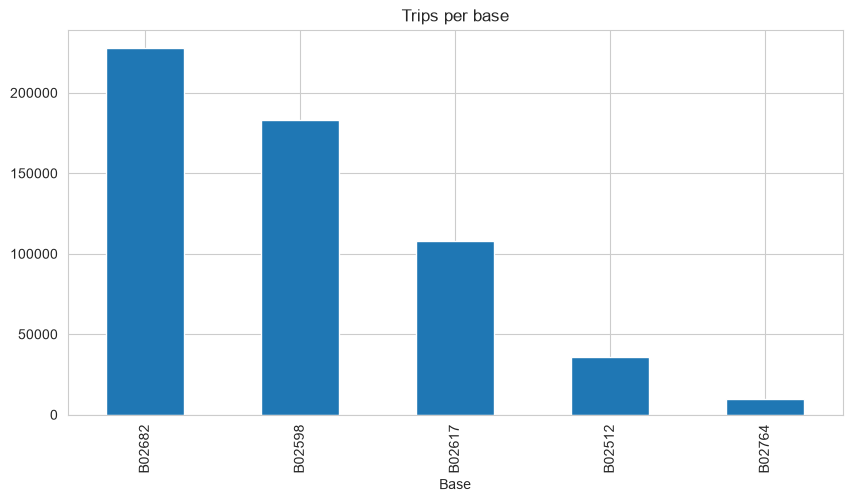

In [6]:
# Trips per base/company
df['Base'].value_counts().plot(kind='bar', title='Trips per base')
plt.show()

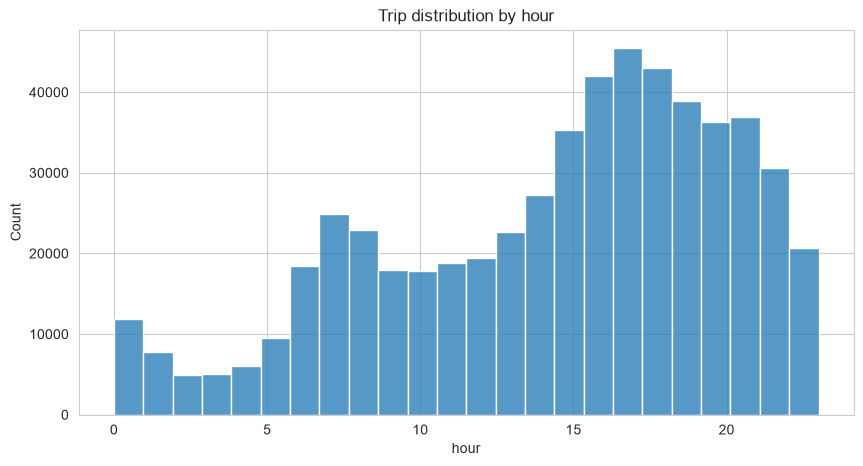

In [7]:
# Distribution of trips across hours of the day
sns.histplot(df['hour'], bins=24, kde=False)
plt.title('Trip distribution by hour')
plt.show()

## 3. Bivariate analysis

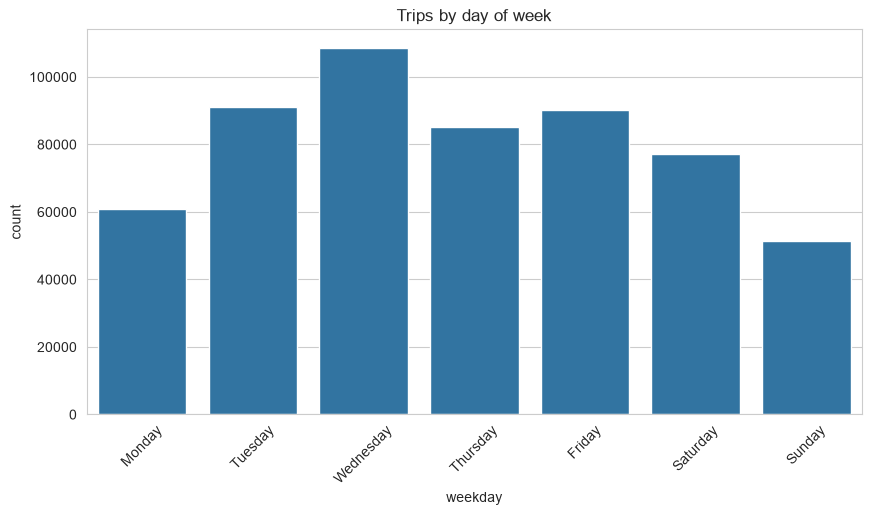

In [8]:
# Trips by weekday
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.countplot(data=df, x='weekday', order=order)
plt.xticks(rotation=45)
plt.title('Trips by day of week')
plt.show()

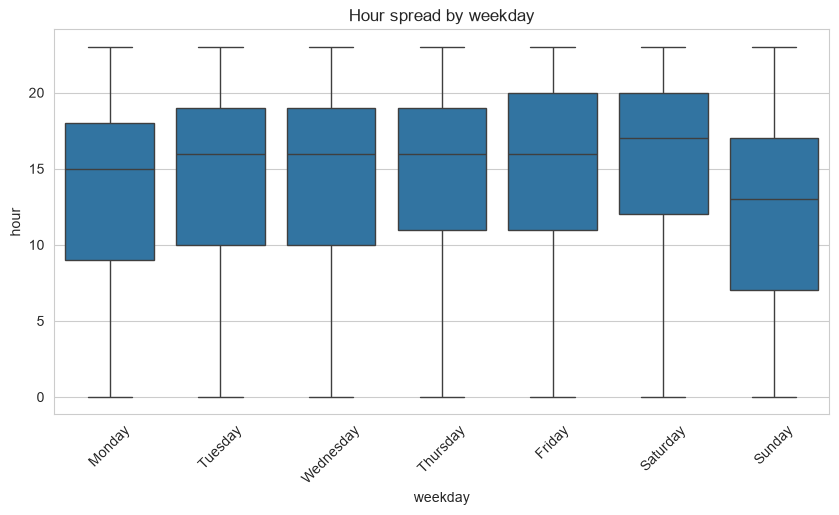

In [9]:
# Hour vs weekday
sns.boxplot(data=df, x='weekday', y='hour', order=order)
plt.xticks(rotation=45)
plt.title('Hour spread by weekday')
plt.show()

## 4. Multivariate & temporal analysis

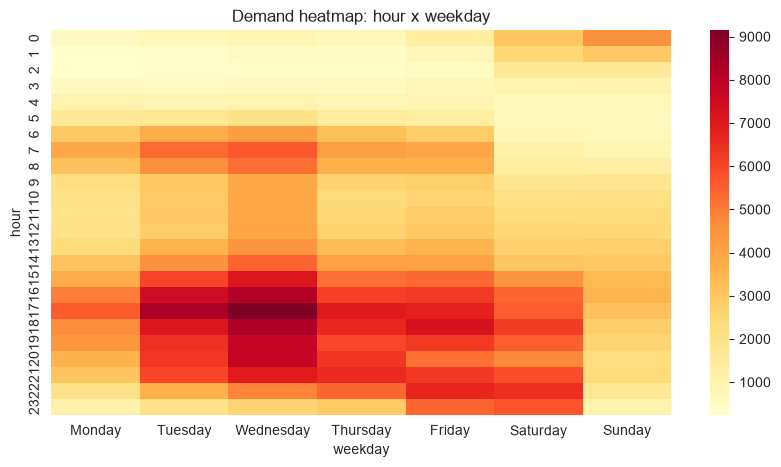

In [10]:
# Heatmap: hour x weekday demand
pivot = df.pivot_table(index='hour', columns='weekday', values='Base', aggfunc='count')
pivot = pivot[order]
sns.heatmap(pivot, cmap='YlOrRd')
plt.title('Demand heatmap: hour x weekday')
plt.show()

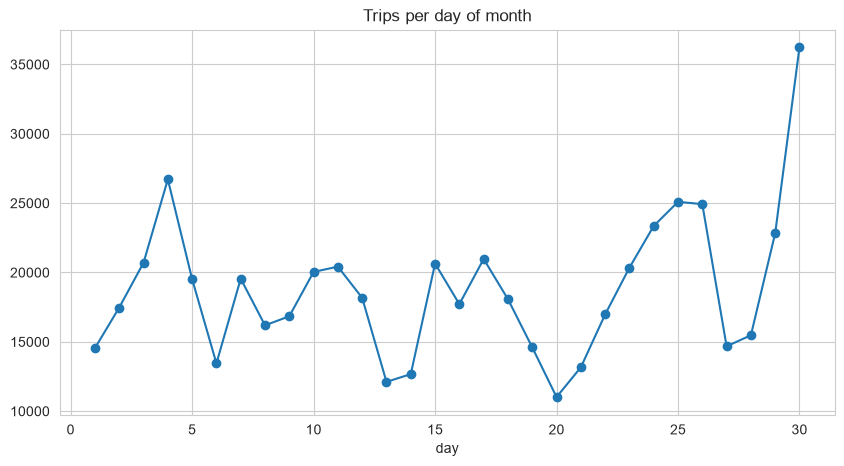

In [11]:
# Daily trend across the month
df.groupby('day').size().plot(kind='line', marker='o', title='Trips per day of month')
plt.show()

## 5. Key insights

- **Peak demand is evening rush, 4-6 PM** — trips climb steadily through the day and peak around hour 17 (~46,000 trips), with a smaller secondary bump at 7-8 AM (~24,000-25,000) for the morning commute. The overnight lull (2-4 AM) is the quietest stretch.
- **Wednesday is the busiest day** (~105,000 trips), followed closely by Tuesday and Friday; Sunday is the quietest (~48,000) — roughly half of Wednesday's volume.
- **Base B02682 dominates volume** with ~215,000 trips, well ahead of B02598 (~180,000) and B02617 (~105,000) — likely reflects a larger fleet size or wider coverage area for that base.
- **Weekends shift later and spread wider** — the hour-by-weekday heatmap and boxplots show Saturday and Sunday demand stretching further into late evening/night hours, while weekday demand stays tightly clustered around the 8 AM and 5 PM commute windows.
- **Real-world tie-in:** this is the exact hour/weekday signal Uber, Ola, and Rapido use for surge pricing and driver repositioning — e.g. pre-positioning more drivers on Wednesday evenings between 4-6 PM, when demand peaks hardest.